# Student Grievance Spam Detection System
This notebook demonstrates the development of a machine learning pipeline to distinguish between legitimate student grievances and spam messages.

# Grievance Spam Detection

## 1. Environment Setup & Data Acquisition
In this section, we import necessary libraries and load the grievance dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("grievance_spam_merged.csv")

In [3]:
df.head()

,grievance,label
0,"email attachment size limit is too small, cant...",NOT_SPAM
1,"Dear user, erp maintenance team requires your ...",SPAM
2,URGENT: University IT Helpdesk requires you to...,SPAM
3,"Dear valued user, university portal requires f...",SPAM
4,Final Notice: University portal account deacti...,SPAM


In [4]:
df.isnull().sum()

,0
grievance,0
label,0


### Data Cleaning

In [5]:
df.shape

(1985, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   grievance  1985 non-null   object
 1   label      1985 non-null   object
dtypes: object(2)
memory usage: 31.1+ KB


In [7]:
df.head()

,grievance,label
0,"email attachment size limit is too small, cant...",NOT_SPAM
1,"Dear user, erp maintenance team requires your ...",SPAM
2,URGENT: University IT Helpdesk requires you to...,SPAM
3,"Dear valued user, university portal requires f...",SPAM
4,Final Notice: University portal account deacti...,SPAM


In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
le = LabelEncoder()

In [10]:
df['label'] = le.fit_transform(df['label'])

In [11]:
df.head()

,grievance,label
0,"email attachment size limit is too small, cant...",0
1,"Dear user, erp maintenance team requires your ...",1
2,URGENT: University IT Helpdesk requires you to...,1
3,"Dear valued user, university portal requires f...",1
4,Final Notice: University portal account deacti...,1


In [12]:
df.isnull().sum()

,0
grievance,0
label,0


In [13]:
df.duplicated().sum()

np.int64(1)

In [14]:
df = df.drop_duplicates(ignore_index=True)
print(df.shape)

(1984, 2)


### EDA

In [15]:
df['label'].value_counts()

,count
label,
1,993
0,991


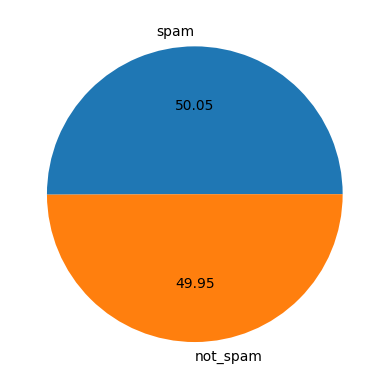

In [16]:
plt.pie(df['label'].value_counts(),labels=['spam','not_spam'],autopct='%0.2f')
plt.show()

We have created balanced dataset manually.

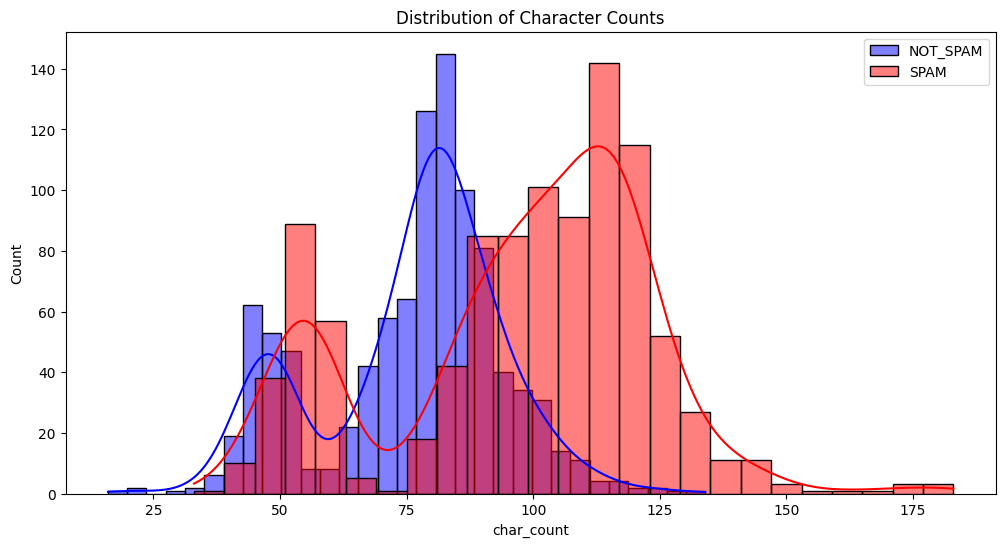

In [63]:
from wordcloud import WordCloud

# Calculate message lengths
df['char_count'] = df['grievance'].apply(len)
df['word_count'] = df['grievance'].apply(lambda x: len(x.split()))

# Plot distribution of message lengths
plt.figure(figsize=(12, 6))
sns.histplot(df[df['label'] == 0]['char_count'], label='NOT_SPAM', kde=True, color='blue')
sns.histplot(df[df['label'] == 1]['char_count'], label='SPAM', kde=True, color='red')
plt.title('Distribution of Character Counts')
plt.legend()
plt.show()

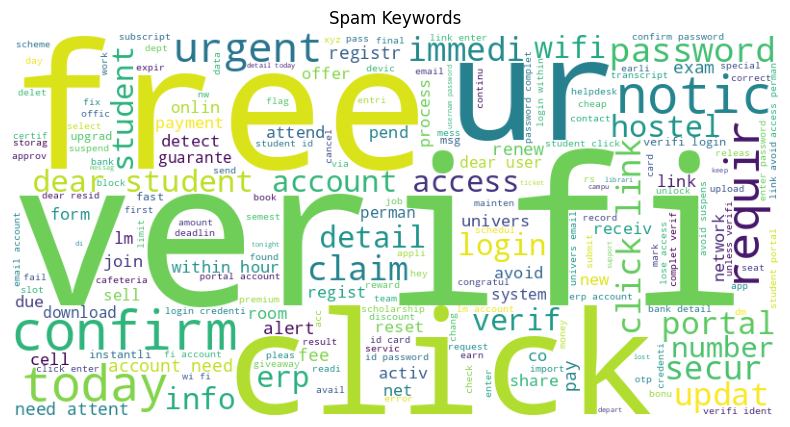

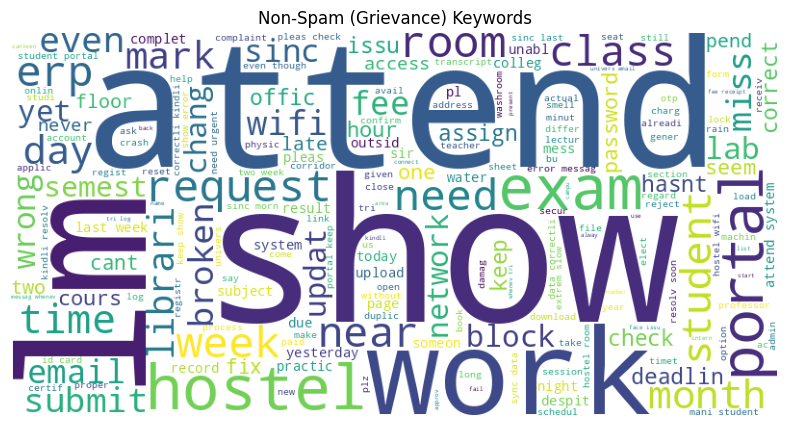

In [64]:
def generate_wordcloud(label, title):
    wc = WordCloud(width=800, height=400, background_color='white').generate(" ".join(df[df['label'] == label]['transformed_grievance']))
    plt.figure(figsize=(10, 5))
    plt.imshow(wc)
    plt.title(title)
    plt.axis('off')
    plt.show()

generate_wordcloud(1, 'Spam Keywords')
generate_wordcloud(0, 'Non-Spam (Grievance) Keywords')

In [17]:
import nltk

In [18]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [19]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [20]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [21]:
pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 9.9 MB/s eta 0:00:00


### Data Preprocessing

## 2. Advanced Text Preprocessing
We implement a robust preprocessing pipeline that handles:
* **HTML & Noise Removal**: Stripping tags and special characters.
* **Normalization**: Expanding contractions and handling repeated characters.
* **Feature Engineering**: Converting emojis to text and preserving placeholder tokens for URLs/Emails.
* **NLP Optimization**: Stemming and custom stop-word removal.

In [29]:
import re
import emoji
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize


stemmer = PorterStemmer()

# Preserve negations because they change meaning
NEGATIONS = {
    "no",
    "not",
    "nor",
    "never",
    "cannot",
    "without"
}

stop_words = set(stopwords.words("english")) - NEGATIONS

# ----------------------------------------------------
# Compiled Regular Expressions
# ----------------------------------------------------
URL_RE = re.compile(r"https?://\S+|www\.\S+")

EMAIL_RE = re.compile(
    r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b"
)

PHONE_RE = re.compile(
    r"\b(?:\+?\d{1,3}[-.\s]?)?(?:\d{10}|\d{3}[-.\s]?\d{3}[-.\s]?\d{4})\b"
)

HTML_RE = re.compile(r"<.*?>")

MENTION_RE = re.compile(r"@\w+")

HASHTAG_RE = re.compile(r"#(\w+)")

# Keep lowercase letters, digits and spaces
NON_ALNUM_RE = re.compile(r"[^a-z0-9\s]")

MULTISPACE_RE = re.compile(r"\s+")

# pleaaaaase -> pleaase
REPEAT_RE = re.compile(r"(.)\1{2,}")

# ----------------------------------------------------
# Contractions
# ----------------------------------------------------
CONTRACTIONS = {
    "can't": "cannot",
    "won't": "will not",
    "n't": " not",
    "'re": " are",
    "'ve": " have",
    "'ll": " will",
    "'d": " would",
    "'m": " am",
    "'s": ""
}


def expand_contractions(text):
    """Expand common English contractions."""
    for key, value in CONTRACTIONS.items():
        text = text.replace(key, value)
    return text


def transform_text(text):
    """
    Text preprocessing optimized for

    University Grievance Spam Detection

    Model:
        TF-IDF + Multinomial Naive Bayes
    """

    # ------------------------------------------
    # Handle missing values
    # ------------------------------------------
    if not isinstance(text, str):
        return ""

    text = text.strip()

    if not text:
        return ""

    # ------------------------------------------
    # Remove HTML
    # ------------------------------------------
    text = HTML_RE.sub(" ", text)

    # ------------------------------------------
    # Lowercase
    # ------------------------------------------
    text = text.lower()

    # ------------------------------------------
    # Expand contractions
    # can't -> cannot
    # ------------------------------------------
    text = expand_contractions(text)

    # ------------------------------------------
    # Replace URLs, Emails and Phone Numbers
    # ------------------------------------------
    text = URL_RE.sub(" urltoken ", text)
    text = EMAIL_RE.sub(" emailtoken ", text)
    text = PHONE_RE.sub(" phonetoken ", text)

    # ------------------------------------------
    # Remove mentions
    # ------------------------------------------
    text = MENTION_RE.sub(" ", text)

    # ------------------------------------------
    # Keep hashtag words
    # #urgent -> urgent
    # ------------------------------------------
    text = HASHTAG_RE.sub(r" \1 ", text)

    # ------------------------------------------
    # Convert emojis into words
    # 😊 -> smiling_face
    # ------------------------------------------
    text = emoji.demojize(text, delimiters=(" ", " "))
    text = text.replace("_", " ")

    # ------------------------------------------
    # Normalize repeated characters
    # pleaaaaase -> pleaase
    # ------------------------------------------
    text = REPEAT_RE.sub(r"\1\1", text)

    # ------------------------------------------
    # Remove punctuation
    # Keep numbers
    # ------------------------------------------
    text = NON_ALNUM_RE.sub(" ", text)

    # ------------------------------------------
    # Remove extra spaces
    # ------------------------------------------
    text = MULTISPACE_RE.sub(" ", text).strip()

    # ------------------------------------------
    # Tokenize
    # ------------------------------------------
    tokens = word_tokenize(text)

    cleaned = []

    # Preserve placeholder tokens
    SPECIAL_TOKENS = {
        "urltoken",
        "emailtoken",
        "phonetoken"
    }

    for token in tokens:

        # Preserve placeholders
        if token in SPECIAL_TOKENS:
            cleaned.append(token)
            continue

        # Remove stopwords except negations
        if token in stop_words:
            continue

        # Remove single alphabetic characters
        if len(token) == 1 and token.isalpha():
            continue

        # Stem words
        cleaned.append(stemmer.stem(token))

    return " ".join(cleaned)

In [30]:
print(transform_text("Click here to verify your account: https://fake-bank.com/login"))

click verifi account urltoken


In [31]:
transform_text("😂❤️😱💸🔥💰")

'face tear joy red heart face scream fear money wing fire money bag'

In [32]:
transform_text("The hostel room is not clean and the washroom is always dirty.")

'hostel room not clean washroom alway dirti'

In [33]:
transform_text("Contact admin@gmail.com immediately.")

'contact emailtoken immedi'

In [34]:
transform_text("Call me at +977-9812345678")

'call phonetoken'

In [35]:
transform_text("Call me at 9812345678")

'call phonetoken'

In [36]:
transform_text("The hostel room is not clean.")

'hostel room not clean'

In [37]:
transform_text("🎉 Congratulations! Claim your prize.")

'parti popper congratul claim prize'

In [38]:
df['transformed_grievance'] = df['grievance'].apply(transform_text)

In [39]:
df.head()

,grievance,label,transformed_grievance
0,"email attachment size limit is too small, cant...",0,email attach size limit small cant submit proj...
1,"Dear user, erp maintenance team requires your ...",1,dear user erp mainten team requir password con...
2,URGENT: University IT Helpdesk requires you to...,1,urgent univers helpdesk requir confirm passwor...
3,"Dear valued user, university portal requires f...",1,dear valu user univers portal requir fresh log...
4,Final Notice: University portal account deacti...,1,final notic univers portal account deactiv sch...


### Model Building

## 3. Model Development & Hyperparameter Tuning
We utilize a **Multinomial Naive Bayes** classifier paired with **TF-IDF Vectorization**. We perform a grid search to optimize hyperparameters like `alpha` and `ngram_range` for maximum accuracy.

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['transformed_grievance'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [43]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [44]:
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

In [45]:
X_train.shape

(1587, 3043)

In [46]:
y_train.shape

(1587,)

In [47]:
X_test.shape

(397, 3043)

In [48]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 20981 stored elements and shape (1587, 3043)>

In [49]:
X_train = X_train.toarray()
X_test = X_test.toarray()

In [50]:
y_train

,label
549,0
1233,0
1165,1
293,1
1078,0
...,...
1249,0
10,1
74,1
651,0


In [51]:
y_test.shape

(397,)

In [52]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [53]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [54]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.947103274559194
[[189   9]
 [ 12 187]]
0.9540816326530612


In [55]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9546599496221663
[[188  10]
 [  8 191]]
0.9502487562189055


In [56]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9622166246851386
[[195   3]
 [ 12 187]]
0.9842105263157894


In [57]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       0.94      0.95      0.95       198
           1       0.95      0.94      0.95       199

    accuracy                           0.95       397
   macro avg       0.95      0.95      0.95       397
weighted avg       0.95      0.95      0.95       397



In [58]:
print("Train Accuracy:", mnb.score(X_train, y_train))
print("Test Accuracy:", mnb.score(X_test, y_test))

Train Accuracy: 0.9930686830497795
Test Accuracy: 0.9546599496221663


In [60]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)),
    ('clf', MultinomialNB())
])

scores = cross_val_score(
    pipeline,
    df['transformed_grievance'],   # Raw text
    df['label'],
    cv=5,
    scoring='accuracy'
)

print(scores)
print("Mean Accuracy:", scores.mean())

[0.94962217 0.98740554 0.99496222 0.92191436 0.96464646]
Mean Accuracy: 0.9637101493524668


In [61]:
pipeline.fit(
    df['transformed_grievance'],
    df['label']
)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, min_df=2, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('clf', MultinomialNB())])

In [62]:
#new_text = ["Urgent: My examination form has not been accepted"]
new_text = ["Please click here to get a free iPhone."]

prediction = pipeline.predict(new_text)

print(prediction)

[1]


### Hyperparameter Tuning

We will use `GridSearchCV` to find the best parameters for both the TF-IDF vectorizer and the MultinomialNB classifier.

In [67]:
from sklearn.model_selection import GridSearchCV

# Define the pipeline
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True)),
    ('mnb', MultinomialNB())
])

# Define parameter grid
param_grid = {
    'tfidf__max_df': [0.90, 0.95, 1.0],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'mnb__alpha': [0.1, 0.5, 1.0, 2.0]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit on training text data
grid_search.fit(X_train_text, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'mnb__alpha': 0.1, 'tfidf__max_df': 0.9, 'tfidf__ngram_range': (1, 2)}
Best Cross-Validation Score: 0.9773


In [68]:
# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test_text, y_test)

print(f"Test Accuracy of the optimized model: {test_accuracy:.4f}")

Test Accuracy of the optimized model: 0.9647


Classification Report for Optimized MultinomialNB:
              precision    recall  f1-score   support

  LEGITIMATE       0.96      0.97      0.96       198
        SPAM       0.97      0.96      0.96       199

    accuracy                           0.96       397
   macro avg       0.96      0.96      0.96       397
weighted avg       0.96      0.96      0.96       397



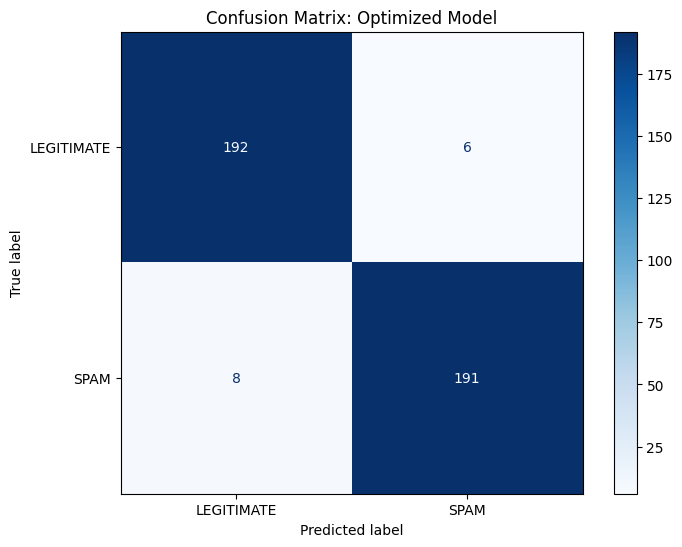

In [73]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Predictions from the optimized model
y_pred_optimized = best_model.predict(X_test_text)

# 2. Classification Report
print("Classification Report for Optimized MultinomialNB:")
print(classification_report(y_test, y_pred_optimized, target_names=['LEGITIMATE', 'SPAM']))

# 3. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred_optimized)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['LEGITIMATE', 'SPAM'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Optimized Model')
plt.show()

### Model Export for Web Deployment
We will use `pickle` to save the model. This file contains the entire pipeline (TF-IDF + MultinomialNB).

## 4. Final Evaluation & Model Export
Finally, we evaluate the model using a confusion matrix and classification report before serializing the pipeline for production use.

In [69]:
import pickle

# Save the best model pipeline to a file
with open('grievance_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Model successfully dumped as 'grievance_model.pkl'")

Model successfully dumped as 'grievance_model.pkl'


### How to use the dumped model in Web App

To use this in a Python backend (like Flask), you need to follow these steps:

1. **Copy the `transform_text` function**: Your model was trained on preprocessed text, so your web app must use the exact same cleaning logic before predicting.
2. **Load the file**: Use `pickle.load()`.
3. **Predict**: Pass the transformed text to the model.

**Example Code for  Web Server:**
```python
import pickle

# 1. Load the model
with open('grievance_model.pkl', 'rb') as f:
    model = pickle.load(f)

# 2. Define the input
user_input = "I need help with my hostel room..."

# 3. Preprocess (Crucial: Use the same transform_text function defined earlier)
cleaned_text = transform_text(user_input)

# 4. Predict
# Note: The model expects a list/array
result = model.predict([cleaned_text])

if result[0] == 1:
    print("This is SPAM")
else:
    print("This is a legitimate GRIEVANCE")
```

In [74]:
import pickle

# 1. Load the model
with open('grievance_model.pkl', 'rb') as f:
    model = pickle.load(f)

# 2. Define the input
user_input = ""

# 3. Preprocess (Crucial: Use the same transform_text function defined earlier)
cleaned_text = transform_text(user_input)

# 4. Predict
# Note: The model expects a list/array
result = model.predict([cleaned_text])

if result[0] == 1:
    print("This is SPAM")
else:
    print("This is a legitimate GRIEVANCE")

This is SPAM


### Testing the Model with 10 Sample Cases
We will now pass 10 different strings through the preprocessing and prediction pipeline to see how the model categorizes them.

In [ ]:
test_cases = [
    "I am facing issues with my scholarship disbursement for this semester.",
    "URGENT: Your student account password has expired. Click here to reset: http://fake-uni.com",
    "The library air conditioning is not working properly in the reading room.",
    "c",
    "I would like to request an extension for my final year project submission.",
    "Win a free iPhone 15 by completing this short survey now!",
    "The mess food quality has been very poor lately, please look into it.",
    "Verify your bank account details immediately to avoid suspension.",
    "Can you please help me with the course registration process for elective subjects?",
    "Get rich quick! Work from home and earn 1000 dollars a day."
]

results = []
for text in test_cases:
    cleaned = transform_text(text)
    # Predict using the loaded model pipeline
    pred = model.predict([cleaned])[0]
    label = "SPAM" if pred == 1 else "LEGITIMATE"
    results.append({"Message": text, "Prediction": label})

# Display as a DataFrame for better readability
test_df = pd.DataFrame(results)
display(test_df)

,Message,Prediction
0,I am facing issues with my scholarship disburs...,LEGITIMATE
1,URGENT: Your student account password has expi...,SPAM
2,The library air conditioning is not working pr...,LEGITIMATE
3,Congratulations! You have been selected for a ...,SPAM
4,I would like to request an extension for my fi...,LEGITIMATE
5,Win a free iPhone 15 by completing this short ...,SPAM
6,The mess food quality has been very poor latel...,LEGITIMATE
7,Verify your bank account details immediately t...,SPAM
8,Can you please help me with the course registr...,LEGITIMATE
9,Get rich quick! Work from home and earn 1000 d...,SPAM
